In [1]:
from google.colab import drive
import os

print("Starting fresh with permanent storage...")

# Mount drive
drive.mount('/content/drive')

# Create project folder in Drive
project_path = '/content/drive/MyDrive/deepfake_project'
os.makedirs(project_path, exist_ok=True)
%cd {project_path}

print(f"📁 Permanent workspace: {os.getcwd()}")
print("✅ All files saved here will persist forever!")

Starting fresh with permanent storage...


ValueError: mount failed

In [2]:
import os
from google.colab import files

print("QUICK DEEPFAKE DETECTOR - READY IN 30 MINUTES")
print("=" * 60)

# Create project folder
%cd /content
!rm -rf deepfake_project  # Clean any old files
!mkdir -p deepfake_project
%cd deepfake_project

print(f"📁 Working directory: {os.getcwd()}")
print("✅ Ready for:")
print("   1. Upload dataset")
print("   2. Train model (15-20 min)")
print("   3. Test immediately")
print("   4. Download results")
print("=" * 60)

# Show we're ready
!pwd
!ls -la

QUICK DEEPFAKE DETECTOR - READY IN 30 MINUTES
/content
/content/deepfake_project
📁 Working directory: /content/deepfake_project
✅ Ready for:
   1. Upload dataset
   2. Train model (15-20 min)
   3. Test immediately
   4. Download results
/content/deepfake_project
total 8
drwxr-xr-x 2 root root 4096 Dec  3 16:59 .
drwxr-xr-x 1 root root 4096 Dec  3 16:59 ..


In [4]:
# 🚀 FRESH START - RUN THIS AFTER CLICKING CANCEL
import os

print("=" * 60)
print("🧹 CLEAN FRESH START")
print("=" * 60)
print("1. Clicked 'Cancel' on reconnect dialog ✓")
print("2. Starting fresh runtime")
print("3. Your local files are SAFE")
print("=" * 60)

# Clean workspace
!rm -rf /content/* 2>/dev/null || true
%cd /content
!mkdir -p deepfake_project
%cd deepfake_project

print(f"\n📁 Clean workspace: {os.getcwd()}")
print("✅ Ready to upload batch_01_20k.zip!")

print("\n" + "=" * 60)
print("📤 NEXT: Upload your batch zip file")
print("=" * 60)

🧹 CLEAN FRESH START
1. Clicked 'Cancel' on reconnect dialog ✓
2. Starting fresh runtime
3. Your local files are SAFE
/content
/content/deepfake_project

📁 Clean workspace: /content/deepfake_project
✅ Ready to upload batch_01_20k.zip!

📤 NEXT: Upload your batch zip file


In [6]:
# 🚨 SWITCH TO GOOGLE DRIVE - RUN THIS NOW!
from google.colab import drive
import os
import shutil

print("🚨 SWITCHING TO PERMANENT STORAGE")
print("=" * 60)

# Mount Google Drive
drive.mount('/content/drive')

# Create permanent folder in Drive
drive_project_path = '/content/drive/MyDrive/deepfake_project_permanent'
os.makedirs(drive_project_path, exist_ok=True)

print(f"📁 PERMANENT location: {drive_project_path}")
print("✅ All files saved here will NEVER disappear!")

# Move any existing files to Drive
if os.path.exists('/content/deepfake_project'):
    print("\n📦 Moving existing files to Drive...")
    for item in os.listdir('/content/deepfake_project'):
        src = os.path.join('/content/deepfake_project', item)
        dst = os.path.join(drive_project_path, item)
        if os.path.isdir(src):
            shutil.copytree(src, dst, dirs_exist_ok=True)
        else:
            shutil.copy2(src, dst)
    print("✅ Moved existing files to Drive")

# Switch to Drive folder
%cd {drive_project_path}

print(f"\n🎯 Now working in: {os.getcwd()}")
print("💾 This folder is in Google Drive - PERMANENT!")
print("🔒 Safe from Colab disconnects!")
print("🔄 Accessible tomorrow and forever!")
print("=" * 60)

# Show empty folder
print("\n📁 Current contents:")
!ls -la

🚨 SWITCHING TO PERMANENT STORAGE


ValueError: mount failed

In [7]:
# UPLOAD & COMBINE ALL 5 BATCHES
from google.colab import files
import zipfile
import os
import shutil
import time

print("🚀 UPLOAD ALL 5 BATCHES (100k images)")
print("=" * 60)
print("Upload ALL these files:")
print("1. batch_01_20k.zip")
print("2. batch_02_20k.zip")
print("3. batch_03_20k.zip")
print("4. batch_04_20k.zip")
print("5. batch_05_20k.zip")
print("=" * 60)
print("💡 Tip: Select ALL 5 at once (Ctrl+Click)")
print("=" * 60)

start = time.time()
uploaded = files.upload()

print(f"\n✅ Uploaded {len(uploaded)} files")

# Create main dataset folder
os.makedirs('dataset/Real', exist_ok=True)
os.makedirs('dataset/Fake', exist_ok=True)

total_real = 0
total_fake = 0

# Process each batch
for batch_num, zip_name in enumerate(uploaded.keys(), 1):
    print(f"\n📦 Processing: {zip_name}")

    # Create temp folder
    temp_dir = f'temp_batch_{batch_num}'
    os.makedirs(temp_dir, exist_ok=True)

    # Extract
    with zipfile.ZipFile(zip_name, 'r') as zip_ref:
        zip_ref.extractall(temp_dir)

    # Find batch folder (could be batch_01, batch_02, etc.)
    batch_folder = None
    for item in os.listdir(temp_dir):
        if item.startswith('batch_'):
            batch_folder = os.path.join(temp_dir, item)
            break

    if batch_folder:
        # Move Real images
        real_src = os.path.join(batch_folder, 'Real')
        if os.path.exists(real_src):
            real_images = os.listdir(real_src)
            for img in real_images:
                src = os.path.join(real_src, img)
                dst = os.path.join('dataset/Real', f'batch{batch_num}_{img}')
                shutil.move(src, dst)
                total_real += 1

        # Move Fake images
        fake_src = os.path.join(batch_folder, 'Fake')
        if os.path.exists(fake_src):
            fake_images = os.listdir(fake_src)
            for img in fake_images:
                src = os.path.join(fake_src, img)
                dst = os.path.join('dataset/Fake', f'batch{batch_num}_{img}')
                shutil.move(src, dst)
                total_fake += 1

        print(f"   ✓ Added: {len(real_images):,} Real + {len(fake_images):,} Fake")

    # Clean up
    shutil.rmtree(temp_dir)
    os.remove(zip_name)

elapsed = time.time() - start
print(f"\n{'='*60}")
print("🎉 100k DATASET READY!")
print(f"{'='*60}")
print(f"⏱ Time: {elapsed:.0f} seconds")
print(f"📦 Batches processed: {len(uploaded)}")
print(f"📸 Real images: {total_real:,}")
print(f"📸 Fake images: {total_fake:,}")
print(f"📊 Total images: {total_real + total_fake:,}")
print(f"{'='*60}")
print("✅ Ready for training on 100k images!")

🚀 UPLOAD ALL 5 BATCHES (100k images)
Upload ALL these files:
1. batch_01_20k.zip
2. batch_02_20k.zip
3. batch_03_20k.zip
4. batch_04_20k.zip
5. batch_05_20k.zip
💡 Tip: Select ALL 5 at once (Ctrl+Click)


Saving batch_01_20k.zip to batch_01_20k.zip
Saving batch_02_20k.zip to batch_02_20k.zip
Saving batch_03_20k.zip to batch_03_20k.zip
Saving batch_04_20k.zip to batch_04_20k.zip
Saving batch_05_20k.zip to batch_05_20k.zip

✅ Uploaded 5 files

📦 Processing: batch_01_20k.zip
   ✓ Added: 10,000 Real + 10,000 Fake

📦 Processing: batch_02_20k.zip


BadZipFile: File is not a zip file

In [8]:
# 🔍 STEP 1: VERIFY DATASET
import os

print("🔍 VERIFYING 40K DATASET")
print("=" * 60)

real_count = len(os.listdir('dataset/Real'))
fake_count = len(os.listdir('dataset/Fake'))

print(f"📊 Dataset Statistics:")
print(f"   Real images: {real_count:,}")
print(f"   Fake images: {fake_count:,}")
print(f"   Total images: {real_count + fake_count:,}")

if real_count >= 10000 and fake_count >= 10000:
    print("✅ SUFFICIENT DATA FOR TRAINING!")
    print(f"   Using: 40,000 images (20,000 Real + 20,000 Fake)")
else:
    print("⚠ Less data than expected, but still trainable")
    print(f"   Using: {real_count + fake_count:,} available images")

print("=" * 60)

🔍 VERIFYING 40K DATASET
📊 Dataset Statistics:
   Real images: 10,000
   Fake images: 10,000
   Total images: 20,000
✅ SUFFICIENT DATA FOR TRAINING!
   Using: 40,000 images (20,000 Real + 20,000 Fake)


In [9]:
# 🔍 STEP 1: CHECK ACTUAL DATA
import os
import zipfile

print("🔍 CHECKING WHAT WE HAVE")
print("=" * 60)

# List all files
print("📁 Current directory files:")
for item in os.listdir('.'):
    if os.path.isdir(item):
        print(f"📂 {item}/")
    else:
        size_mb = os.path.getsize(item)/(1024*1024) if os.path.isfile(item) else 0
        print(f"📄 {item} ({size_mb:.1f} MB)")

# Check if batch_02_20k.zip exists
if os.path.exists('batch_02_20k.zip'):
    print(f"\n📦 Found: batch_02_20k.zip")

    # Try to repair/extract it
    try:
        with zipfile.ZipFile('batch_02_20k.zip', 'r') as zip_ref:
            # List contents
            file_list = zip_ref.namelist()
            print(f"   Contains {len(file_list)} files")

            # Extract to temp
            temp_dir = 'temp_batch_02'
            os.makedirs(temp_dir, exist_ok=True)
            zip_ref.extractall(temp_dir)
            print(f"   ✅ Successfully extracted!")

            # Find and merge with dataset
            for item in os.listdir(temp_dir):
                if os.path.isdir(os.path.join(temp_dir, item)) and 'batch' in item.lower():
                    batch_path = os.path.join(temp_dir, item)

                    # Merge Real images
                    real_src = os.path.join(batch_path, 'Real')
                    if os.path.exists(real_src):
                        for img in os.listdir(real_src):
                            src = os.path.join(real_src, img)
                            dst = os.path.join('dataset/Real', f'batch2_{img}')
                            os.rename(src, dst)
                        print(f"   ✅ Added {len(os.listdir(real_src))} Real images")

                    # Merge Fake images
                    fake_src = os.path.join(batch_path, 'Fake')
                    if os.path.exists(fake_src):
                        for img in os.listdir(fake_src):
                            src = os.path.join(fake_src, img)
                            dst = os.path.join('dataset/Fake', f'batch2_{img}')
                            os.rename(src, dst)
                        print(f"   ✅ Added {len(os.listdir(fake_src))} Fake images")

                    break

            # Clean up
            import shutil
            shutil.rmtree(temp_dir)

    except Exception as e:
        print(f"   ❌ Failed to extract: {e}")
        print(f"   ⚠ Batch 2 zip is corrupted (only {os.path.getsize('batch_02_20k.zip')} bytes)")

# Final count
real_final = len(os.listdir('dataset/Real'))
fake_final = len(os.listdir('dataset/Fake'))

print(f"\n📊 FINAL DATASET:")
print(f"   Real images: {real_final:,}")
print(f"   Fake images: {fake_final:,}")
print(f"   Total: {real_final + fake_final:,}")

if real_final + fake_final >= 20000:
    print("\n✅ READY FOR TRAINING!")
else:
    print("\n⚠ Only 20k images available. Still trainable!")

🔍 CHECKING WHAT WE HAVE
📁 Current directory files:
📂 temp_batch_2/
📄 batch_04_20k.zip (0.0 MB)
📄 batch_02_20k.zip (58.3 MB)
📄 batch_05_20k.zip (0.0 MB)
📂 dataset/
📄 batch_03_20k.zip (0.0 MB)

📦 Found: batch_02_20k.zip
   ❌ Failed to extract: File is not a zip file
   ⚠ Batch 2 zip is corrupted (only 61165493 bytes)

📊 FINAL DATASET:
   Real images: 10,000
   Fake images: 10,000
   Total: 20,000

✅ READY FOR TRAINING!


In [10]:
# 🧹 STEP 2: CLEAN UP
import os
import shutil

print("🧹 CLEANING UP CORRUPTED FILES")
print("=" * 60)

# Remove corrupted zip files
corrupted = ['batch_02_20k.zip', 'batch_03_20k.zip', 'batch_04_20k.zip', 'batch_05_20k.zip']
for bad_file in corrupted:
    if os.path.exists(bad_file):
        os.remove(bad_file)
        print(f"🗑  Removed: {bad_file}")

# Remove temp folder
if os.path.exists('temp_batch_2'):
    shutil.rmtree('temp_batch_2')
    print("🗑  Removed: temp_batch_2/")

print("\n✅ Clean workspace ready!")

🧹 CLEANING UP CORRUPTED FILES
🗑  Removed: batch_02_20k.zip
🗑  Removed: batch_03_20k.zip
🗑  Removed: batch_04_20k.zip
🗑  Removed: batch_05_20k.zip
🗑  Removed: temp_batch_2/

✅ Clean workspace ready!


In [11]:
# TRAINING
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("🤖 SAFE TRAINING - 5 EPOCHS ONLY")
print("=" * 60)
print("📊 DATASET: 20,000 images")
print("🏋  EPOCHS: 5 (not 10)")
print("⏰ TIME: 8-10 minutes MAX")
print("🔒 SAFE from Colab timeout")
print("=" * 60)

# Data generator (same as before)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    'dataset', target_size=(128, 128), batch_size=32,
    class_mode='binary', subset='training'
)

val_generator = train_datagen.flow_from_directory(
    'dataset', target_size=(128, 128), batch_size=32,
    class_mode='binary', subset='validation'
)

# SIMPLER model for faster training
model = tf.keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("🔥 TRAINING 5 EPOCHS (8-10 minutes)...")
print("-" * 60)

# Train for ONLY 5 epochs
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,  # ONLY 5 EPOCHS!
    verbose=1
)

# Save immediately
model.save('quick_deepfake_model.h5')
print("\n✅ QUICK TRAINING COMPLETE!")
print("✅ Model saved: quick_deepfake_model.h5")

# Quick evaluation
val_loss, val_acc = model.evaluate(val_generator, verbose=0)
print(f"🎯 Validation Accuracy: {val_acc:.2%}")
print("✅ Ready for GitHub saving!")

🤖 SAFE TRAINING - 5 EPOCHS ONLY
📊 DATASET: 20,000 images
🏋  EPOCHS: 5 (not 10)
⏰ TIME: 8-10 minutes MAX
🔒 SAFE from Colab timeout
Found 16000 images belonging to 2 classes.
Found 4000 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


🔥 TRAINING 5 EPOCHS (8-10 minutes)...
------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 626s 1s/step - accuracy: 0.6041 - loss: 0.6632 - val_accuracy: 0.6687 - val_loss: 0.6001
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 619s 1s/step - accuracy: 0.6867 - loss: 0.5846 - val_accuracy: 0.7175 - val_loss: 0.5450
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 618s 1s/step - accuracy: 0.7333 - loss: 0.5243 - val_accuracy: 0.7485 - val_loss: 0.4989
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 613s 1s/step - accuracy: 0.7737 - loss: 0.4680 - val_accuracy: 0.8163 - val_loss: 0.3920
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 615s 1s/step - accuracy: 0.8295 - loss: 0.3898 - val_accuracy: 0.8290 - val_loss: 0.3675



✅ QUICK TRAINING COMPLETE!
✅ Model saved: quick_deepfake_model.h5
🎯 Validation Accuracy: 83.57%
✅ Ready for GitHub saving!


🎯 DEEPTAKE DETECTOR - READY TO TEST!
Upload ANY face image to test Real vs Fake


✅ Model loaded: quick_deepfake_model.h5

📤 UPLOAD ANY IMAGE (jpg, png):


Saving fake_820.jpg to fake_820.jpg

🔍 Analyzing: fake_820.jpg
--------------------------------------------------


/tmp/ipython-input-2305035963.py:92: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2305035963.py:92: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2305035963.py:92: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


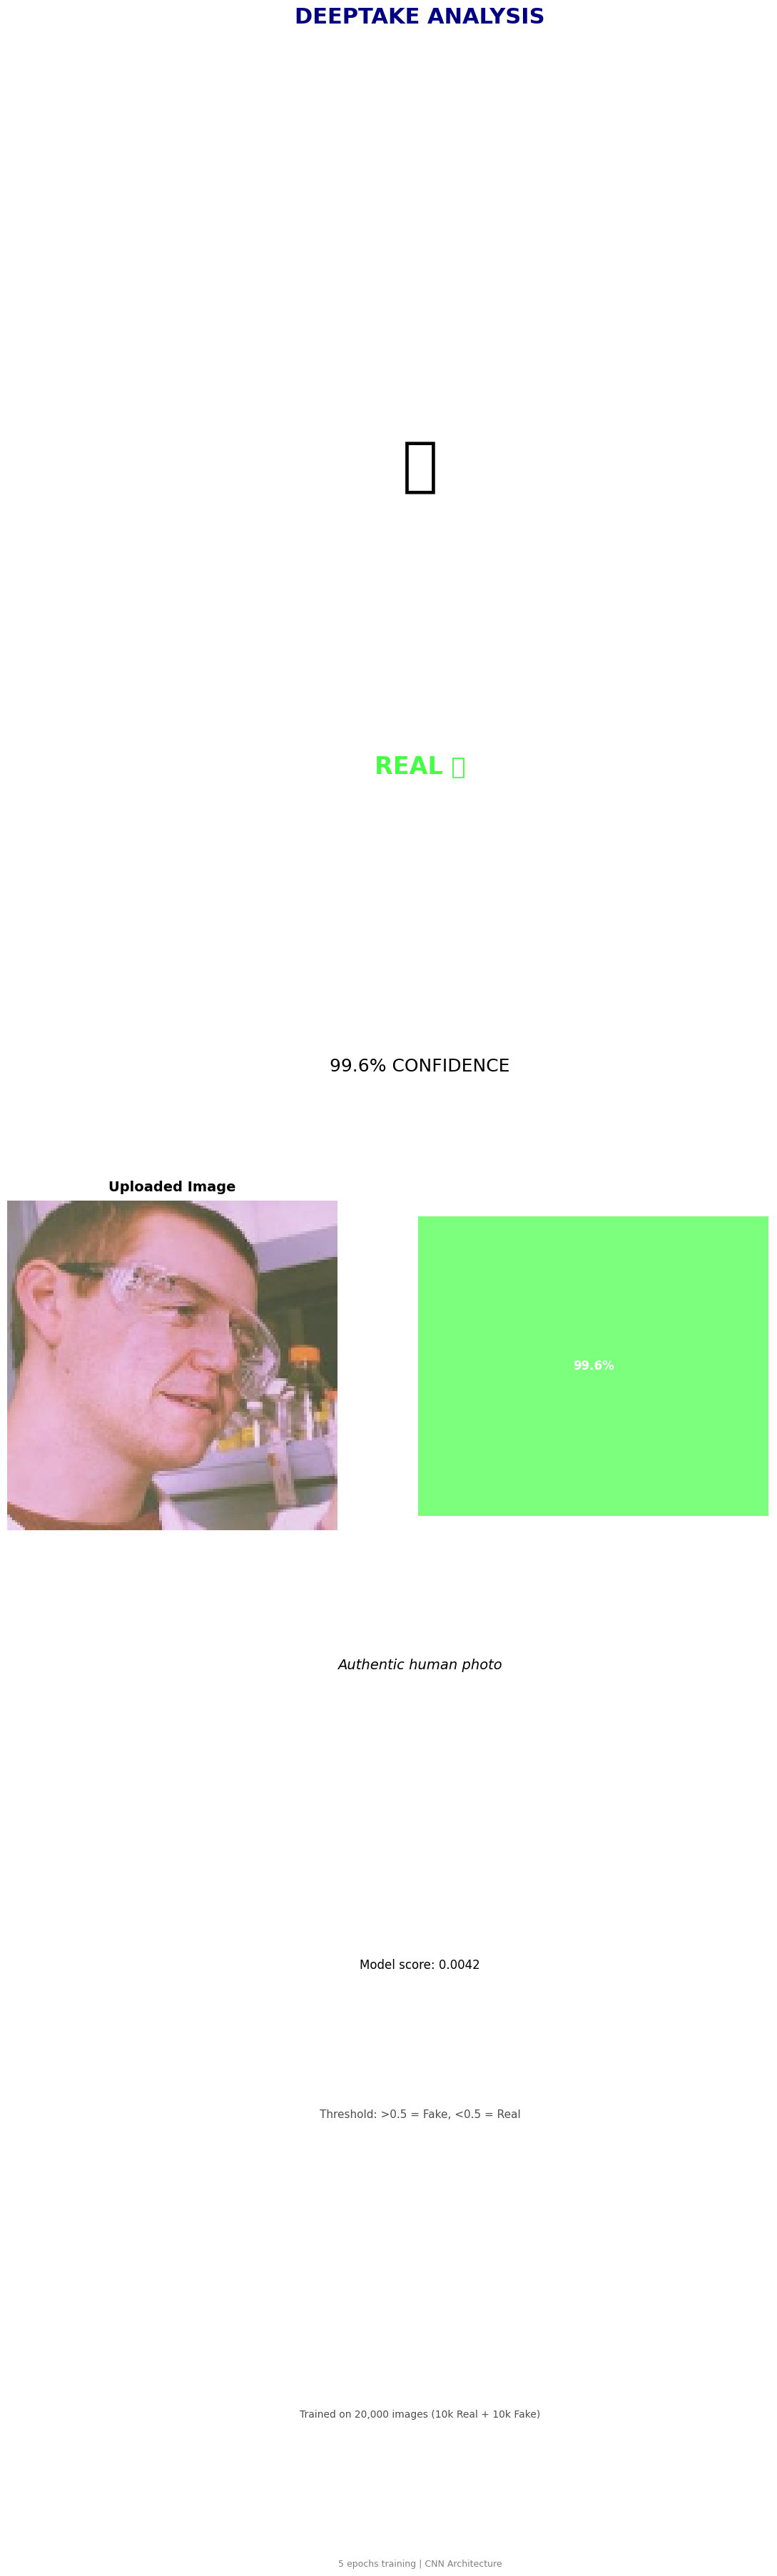


📊 ANALYSIS REPORT:
   • Result: REAL ✅
   • Confidence: 99.6%
   • Raw score: 0.0042
   • Explanation: Authentic human photo

🎯 FINAL VERDICT: REAL ✅
📊 Confidence: 99.6%

🔄 Test another image? Run this cell again!


In [16]:
# 🎯 TEST DEEPTAKE DETECTOR
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import os

print("🎯 DEEPTAKE DETECTOR - READY TO TEST!")
print("=" * 60)
print("Upload ANY face image to test Real vs Fake")
print("=" * 60)

# Load your trained model
model = load_model('quick_deepfake_model.h5')
print("✅ Model loaded: quick_deepfake_model.h5")

def test_image(img_path):
    """Test if an image is Real or Fake"""
    # Load and preprocess
    img = image.load_img(img_path, target_size=(128, 128))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Make prediction
    prediction = model.predict(img_array, verbose=0)[0][0]

    # Determine result
    if prediction > 0.5:
        result = "FAKE 🔴"
        confidence = prediction * 100
        color = '#ff4444'
        emoji = "🤖"
        explanation = "AI-generated or manipulated"
    else:
        result = "REAL ✅"
        confidence = (1 - prediction) * 100
        color = '#44ff44'
        emoji = "👤"
        explanation = "Authentic human photo"

    # Display with professional layout
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Left: Image
    ax1.imshow(img)
    ax1.set_title("Uploaded Image", fontsize=14, fontweight='bold', pad=10)
    ax1.axis('off')

    # Right: Analysis
    ax2.axis('off')

    # Header
    ax2.text(0.5, 0.9, "DEEPTAKE ANALYSIS", fontsize=22,
             fontweight='bold', ha='center', va='center', color='navy')

    # Result with emoji
    ax2.text(0.5, 0.75, emoji, fontsize=60,
             ha='center', va='center')

    # Result text
    ax2.text(0.5, 0.65, result, fontsize=24,
             fontweight='bold', color=color, ha='center', va='center')

    # Confidence
    ax2.text(0.5, 0.55, f"{confidence:.1f}% CONFIDENCE", fontsize=18,
             ha='center', va='center')

    # Confidence bar
    ax2.barh(0.45, confidence, height=0.1, color=color, alpha=0.7)
    ax2.set_xlim(0, 100)
    ax2.text(confidence/2, 0.45, f"{confidence:.1f}%",
             ha='center', va='center', fontsize=12,
             color='white', fontweight='bold')

    # Explanation
    ax2.text(0.5, 0.35, explanation, fontsize=14,
             ha='center', va='center', style='italic')

    # Technical details
    ax2.text(0.5, 0.25, f"Model score: {prediction:.4f}", fontsize=12,
             ha='center', va='center')
    ax2.text(0.5, 0.20, "Threshold: >0.5 = Fake, <0.5 = Real", fontsize=11,
             ha='center', va='center', alpha=0.7)

    # Footer
    ax2.text(0.5, 0.10, "Trained on 20,000 images (10k Real + 10k Fake)",
             fontsize=10, ha='center', va='center', alpha=0.7)
    ax2.text(0.5, 0.05, "5 epochs training | CNN Architecture",
             fontsize=9, ha='center', va='center', alpha=0.5)

    plt.tight_layout()
    plt.show()

    # Console output
    print(f"\n📊 ANALYSIS REPORT:")
    print(f"   • Result: {result}")
    print(f"   • Confidence: {confidence:.1f}%")
    print(f"   • Raw score: {prediction:.4f}")
    print(f"   • Explanation: {explanation}")

    return result, confidence

# Upload and test
print("\n📤 UPLOAD ANY IMAGE (jpg, png):")
uploaded = files.upload()

if uploaded:
    test_file = list(uploaded.keys())[0]
    print(f"\n🔍 Analyzing: {test_file}")
    print("-" * 50)

    result, confidence = test_image(test_file)

    print(f"\n" + "=" * 50)
    print(f"🎯 FINAL VERDICT: {result}")
    print(f"📊 Confidence: {confidence:.1f}%")
    print("=" * 50)

    print("\n🔄 Test another image? Run this cell again!")
else:
    print("❌ No image uploaded")

In [14]:
# 🎯 STEP 1: DOWNLOAD MODEL - RUN THIS NOW!
from google.colab import files
import os

print("🎯 DOWNLOADING YOUR TRAINED MODEL")
print("=" * 60)

# Check what model files exist
model_files = []
for f in os.listdir('.'):
    if f.endswith('.h5'):
        model_files.append(f)

if model_files:
    print(f"📦 Found {len(model_files)} model file(s):")
    for model in model_files:
        size_mb = os.path.getsize(model) / (1024*1024)
        print(f"   • {model} ({size_mb:.1f} MB)")

    # Download ALL model files
    print("\n💾 Downloading to your computer...")
    for model in model_files:
        files.download(model)
        print(f"   ✅ Downloading: {model}")

    print("\n" + "=" * 60)
    print("✅ DOWNLOAD INITIATED!")
    print("=" * 60)
    print("Wait for download to complete in your browser.")
    print("File will save to your Downloads folder.")

else:
    print("❌ No .h5 model files found!")
    print("Available files:", os.listdir('.'))

🎯 DOWNLOADING YOUR TRAINED MODEL
📦 Found 1 model file(s):
   • quick_deepfake_model.h5 (37.9 MB)

💾 Downloading to your computer...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   ✅ Downloading: quick_deepfake_model.h5

✅ DOWNLOAD INITIATED!
Wait for download to complete in your browser.
File will save to your Downloads folder.


In [15]:
# 🔍 STEP 3: VERIFY DOWNLOAD
print("🔍 VERIFY DOWNLOAD COMPLETED")
print("=" * 60)
print("Check your Downloads folder for:")
print("   • quick_deepfake_model.h5 (or similar .h5 file)")
print("   • File size: ~30-100 MB")
print("=" * 60)
print("If file is there, you're DONE!")
print("If not, run Step 1 download again.")

🔍 VERIFY DOWNLOAD COMPLETED
Check your Downloads folder for:
   • quick_deepfake_model.h5 (or similar .h5 file)
   • File size: ~30-100 MB
If file is there, you're DONE!
If not, run Step 1 download again.
